In [15]:
import importlib
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure project root is on sys.path so local modules can be imported
_project_root = str(Path(__file__).resolve().parent.parent) if "__file__" in dir() else str(Path.cwd())
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

# Also add figures_paper to path for figure_config
_figures_paper = str(Path(_project_root) / "figures_paper")
if _figures_paper not in sys.path:
    sys.path.insert(0, _figures_paper)

warnings.filterwarnings("ignore")

# Force reload to pick up any config changes
import figure_config

from common import basedir

importlib.reload(figure_config)
from figure_config import (
    CONTEXT_LABELS,
    MODEL_LABELS,
    configure_axis_spines,
)


In [16]:
# --- Configuration ---
MODEL = "EGFR_MAPK__logobs_tegfr_aggavg"  # tEGFR model
DATASET = "dream_cytof"
FIGURE = "figure3"

model_label = MODEL_LABELS.get(MODEL, MODEL)


def load_sensitivity_data(kind: str, model: str = MODEL, dataset: str = DATASET, figure: str = FIGURE) -> pd.DataFrame:
    """Load sensitivity CSV from eval/{model}/{dataset}/sensitivity_{kind}_{figure}.csv

    Args:
        kind: 'params' or 'latent'
        model: model directory name
        dataset: dataset name
        figure: figure name (e.g. 'figure3')

    Returns:
        DataFrame with sensitivity results
    """
    filepath = basedir / "eval" / model / dataset / f"sensitivity_{kind}_{figure}.csv"
    if not filepath.exists():
        raise FileNotFoundError(f"Sensitivity data not found: {filepath}")
    return pd.read_csv(filepath, index_col=0)


def get_param_sensitivity_order(params_df, context="cytof_init", dataset="val"):
    """Return parameter names ordered by descending mean sensitivity (rmse_diff_zeroed)."""
    subset = params_df[(params_df.context == context) & (params_df.dataset == dataset)]
    return (
        subset.groupby("param")["rmse_diff_zeroed"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

# Parameter Sensitivity

In [53]:
params_df = load_sensitivity_data("params")
param_order = get_param_sensitivity_order(params_df, context="cytof_init", dataset="train")

# Filter to parameters with statistically significant non-zero sensitivity on train
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

train_sub = params_df[(params_df.context == "cytof_init") & (params_df.dataset == "train")]
pvals = {}
for param, grp in train_sub.groupby("param")["rmse_diff_zeroed"]:
    _, p = ttest_1samp(grp.values, 0)
    if np.isnan(p):
        p = 1.0  # If all values are zero, t-test may return nan; treat as non-significant
    pvals[param] = p

pval_series = pd.Series(pvals)
reject, pval_adj, _, _ = multipletests(pval_series.values, method="fdr_bh")
pval_df = pd.DataFrame({"param": pval_series.index, "pval": pval_series.values, "pval_adj": pval_adj, "reject": reject})
sig_params = set(pval_df.loc[pval_df["reject"], "param"])
param_order = [p for p in param_order if p in sig_params]

print(f"Significant parameters (BH-corrected p < 0.05): {len(sig_params)} / {len(pvals)}")
print("Ordered:", param_order)
display(pval_df.sort_values("pval"))

Significant parameters (BH-corrected p < 0.05): 7 / 44
Ordered: ['ERBB2_p_Y1248_ERBB2_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERK_p_Y204_MEK__S222_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw', 'ERK_p_Y204_iMEK_0_kw', 'MEK_p_S222_EGFR__Y1173_p_kw']


,param,pval,pval_adj,reject
28,ERK_p_Y204_iMEK_0_kw,0.000002,0.000070,True
37,RPS6KA1_p_S380_ERK__Y204_p_kw,0.000003,0.000070,True
15,ERBB2_p_Y1248_ERBB2_kw,0.000577,0.008462,True
14,ERBB2_p_Y1248_EGFR__Y1173_p_kw,0.000874,0.009611,True
31,MEK_p_S222_ERBB2__Y1248_p_kw,0.002606,0.022933,True
25,ERK_p_Y204_MEK__S222_p_kw,0.005392,0.039538,True
30,MEK_p_S222_EGFR__Y1173_p_kw,0.007850,0.049340,True
33,MEK_p_S222_ERK__Y204_p_kw,0.010348,0.056917,False
10,EGFR_p_Y1173_iEGFR_0_kw,0.012621,0.061701,False
18,ERBB2_p_Y1248_iEGFR_0_kw,0.027617,0.121515,False


In [51]:
def plot_param_sensitivity_barplot(
    df,
    context,
    datasets=("train", "val"),
    param_order=None,
    top_n=None,
    figsize=(12, 8),
    save_path=None,
):
    """Plot parameter sensitivity distributions for a given context.

    Args:
        df: DataFrame from sensitivity_params CSV
        context: Context to filter ('cytof_init' or 'multimodal')
        datasets: Tuple/list of dataset splits to show
        param_order: List of param names for ordering (None = sort by mean across datasets)
        top_n: If set, show only top N parameters by mean sensitivity
        figsize: Figure size tuple
        save_path: Path to save the figure (None = don't save)
    """
    subset = df[(df.context == context) & (df.dataset.isin(datasets))].copy()

    # Use provided order or compute from data
    if param_order is not None:
        order = [p for p in param_order if p in subset["param"].unique()]
    else:
        order = (
            subset.groupby("param")["rmse_diff_zeroed"]
            .mean()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

    if top_n is not None:
        order = order[:top_n]
        subset = subset[subset["param"].isin(order)]

    context_label = CONTEXT_LABELS.get(context, context)
    ds_label = "/".join(datasets)
    title = f"Parameter Sensitivity – {model_label} ({context_label}, {ds_label})"

    use_hue = len(datasets) > 1
    hue_kwargs = dict(hue="dataset", hue_order=list(datasets)) if use_hue else {}

    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(
        data=subset,
        x="param",
        y="rmse_diff_zeroed",
        order=order,
        showfliers=False,
        width=0.7,
        linewidth=1,
        ax=ax,
        **hue_kwargs,
    )
    sns.swarmplot(
        data=subset,
        x="param",
        y="rmse_diff_zeroed",
        order=order,
        dodge=use_hue,
        size=3,
        alpha=0.75,
        linewidth=0.4,
        edgecolor="white",
        ax=ax,
        **hue_kwargs,
    )

    ax.set_ylabel(r"Sensitivity ($\Delta$RMSE)")
    ax.set_xlabel("Kinetic Parameter")
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    if use_hue:
        handles, labels = ax.get_legend_handles_labels()
        n_labels = len(list(datasets))
        ax.legend(handles[:n_labels], labels[:n_labels], title="Dataset")

    configure_axis_spines(ax)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

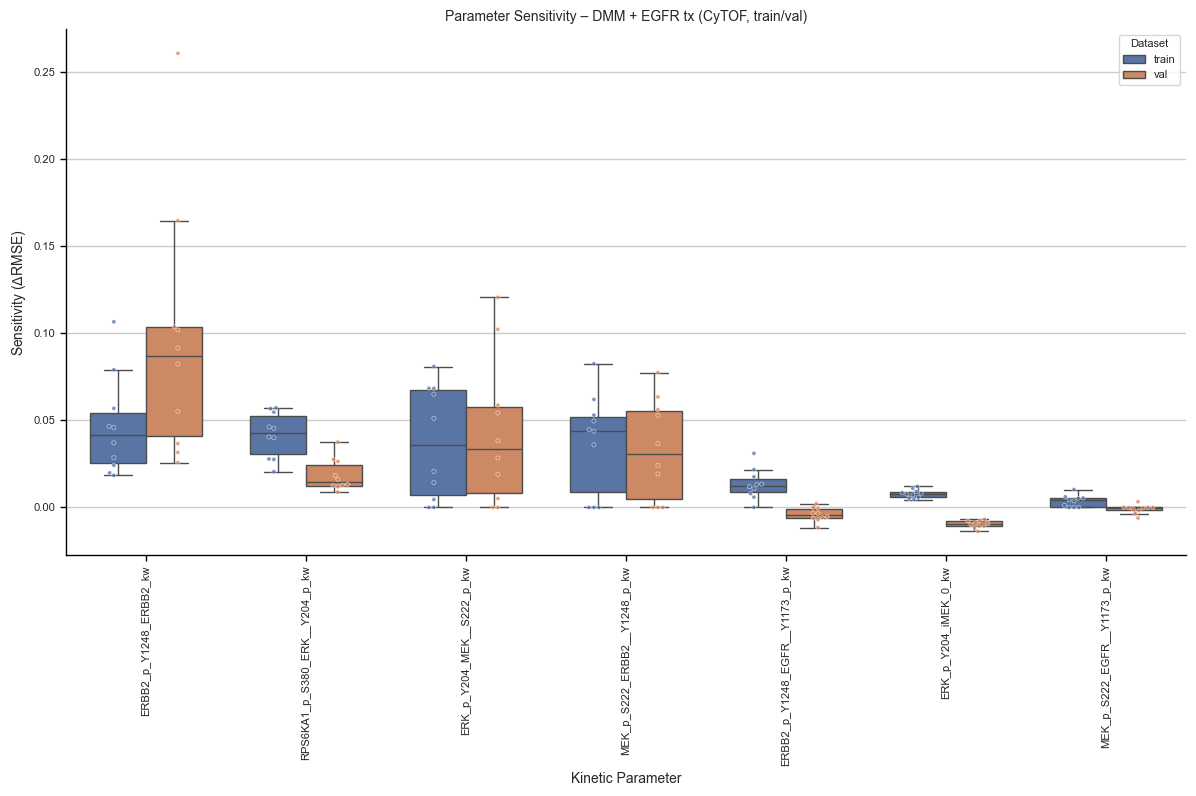

In [40]:
plot_param_sensitivity_barplot(params_df, context="cytof_init", param_order=param_order);

In [54]:
def plot_param_sensitivity_heatmap(
    df,
    context,
    dataset="val",
    param_order=None,
    figsize=(14, 8),
    vmin=None,
    vmax=None,
    cmap="coolwarm",
    save_path=None,
):
    """Plot parameter sensitivity as a heatmap (samples × params).

    Args:
        df: DataFrame from sensitivity_params CSV
        context: Context to filter
        dataset: 'train' or 'val'
        param_order: List of param names for column ordering (None = alphabetical)
        figsize: Figure size tuple
        vmin, vmax: Color scale limits
        cmap: Colormap name
        save_path: Path to save the figure (None = don't save)
    """
    subset = df[(df.context == context) & (df.dataset == dataset)]

    pivot = pd.pivot_table(
        subset,
        values="rmse_diff_zeroed",
        columns="param",
        index="job",
        aggfunc="mean",
    )
    pivot.index.name = "Random Seed"

    # Reorder columns by sensitivity if param_order is given
    if param_order is not None:
        cols = [c for c in param_order if c in pivot.columns]
        pivot = pivot[cols]

    # Turn exact zeros into NaN so they appear as blank cells
    pivot = pivot.replace(0, np.nan)

    # Auto-scale: symmetric around 0 based on non-NaN data if not specified
    if vmin is None or vmax is None:
        abs_max = np.nanmax(np.abs(pivot.values))
        vmin = -abs_max if vmin is None else vmin
        vmax = abs_max if vmax is None else vmax

    context_label = CONTEXT_LABELS.get(context, context)
    title = f"Parameter Sensitivity – {model_label} ({context_label}, {dataset})"

    # Use a copy of the colormap with a distinct background for NaN (masked) cells
    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="#ffffff")  # light gray for NaN / zeroed-out params

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot, cmap=cmap_obj, vmin=vmin, vmax=vmax, center=0,
                xticklabels=pivot.columns, ax=ax, linewidths=0.5, linecolor="white")
    ax.set_title(title)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax

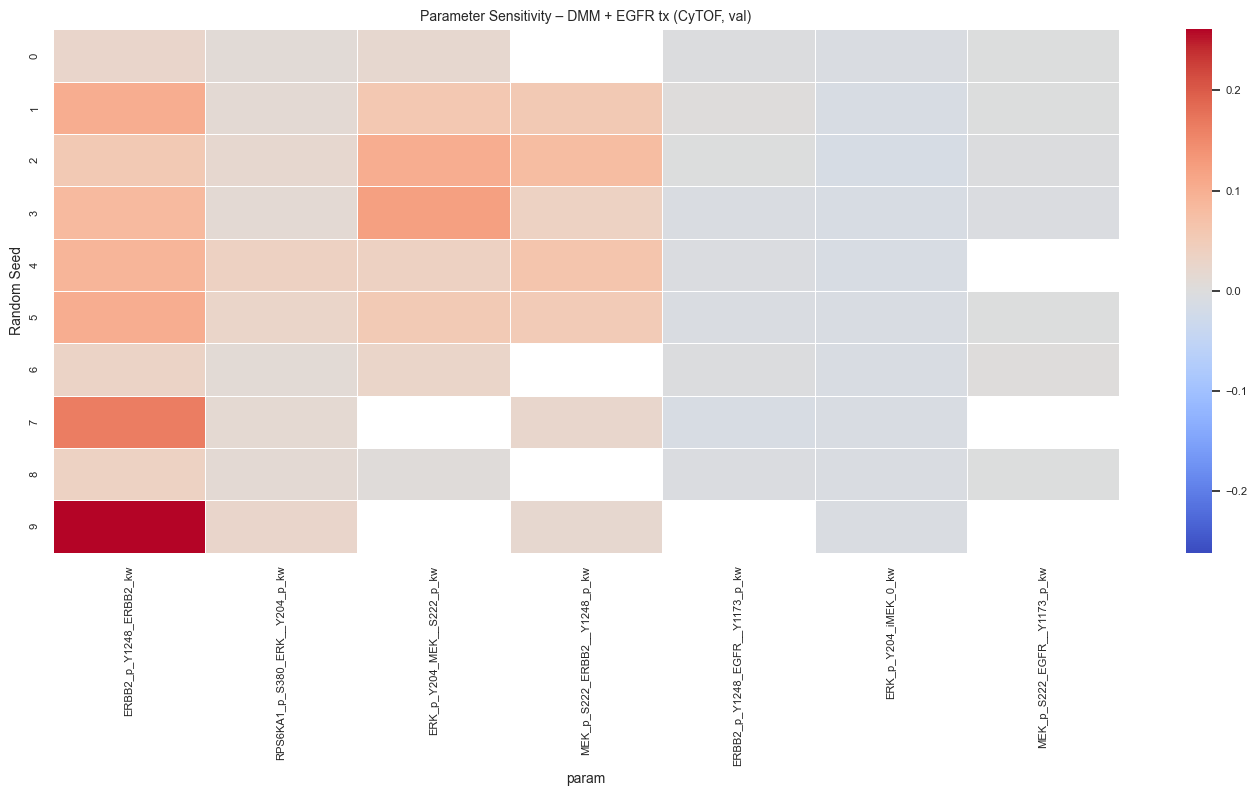

In [55]:
plot_param_sensitivity_heatmap(params_df, context="cytof_init", dataset="val", param_order=param_order);

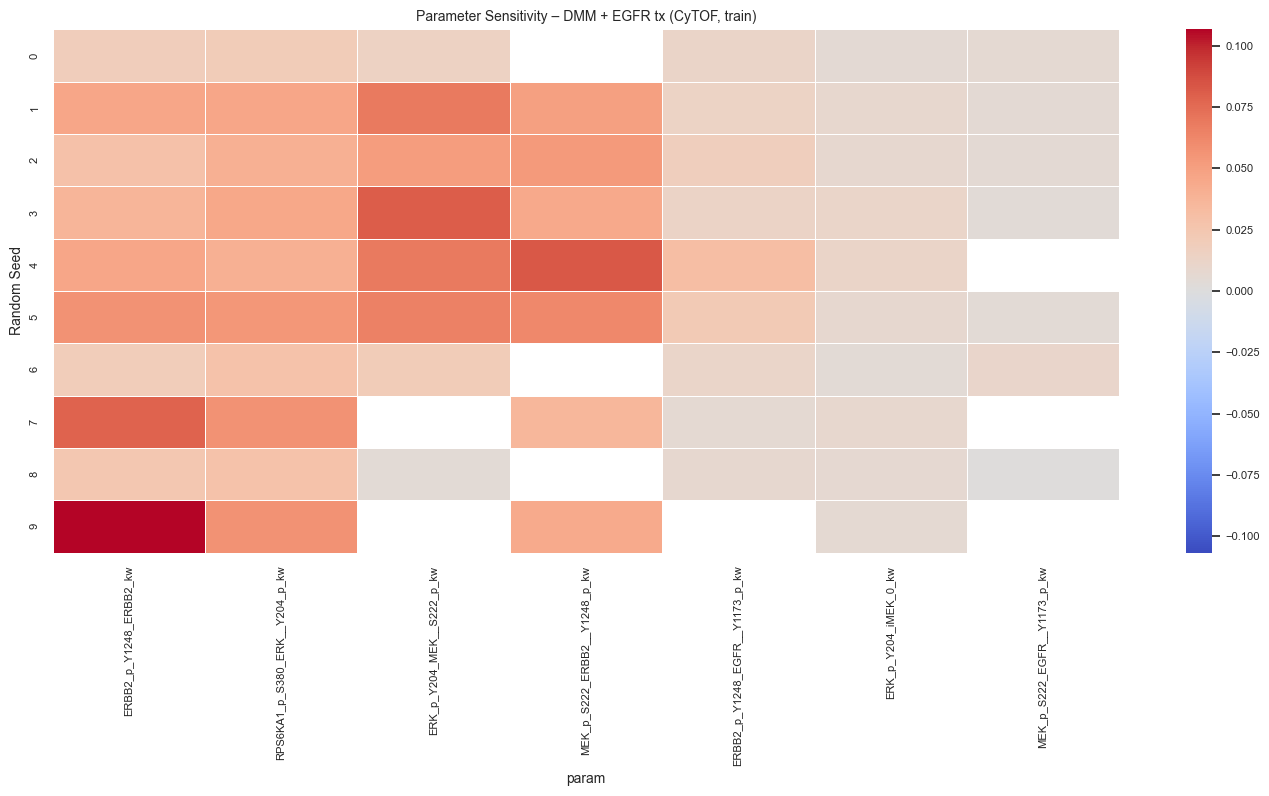

In [56]:
plot_param_sensitivity_heatmap(params_df, context="cytof_init", dataset="train", param_order=param_order);

# Parameter Deviations

In [57]:
def load_param_devs(model: str = MODEL, dataset: str = DATASET, figure: str = FIGURE) -> pd.DataFrame:
    """Load parameter deviations from eval/{model}/{dataset}/param_devs_{figure}.csv"""
    filepath = basedir / "eval" / model / dataset / f"param_devs_{figure}.csv"
    if not filepath.exists():
        raise FileNotFoundError(f"Parameter deviations not found: {filepath}")
    return pd.read_csv(filepath, index_col=0)


# Identify parameter columns (all float columns that are not metadata)
_META_COLS = {
    "cell_line", "context", "samples", "dataset", "job",
    "n_hidden", "depth", "dropout_rate", "nn_init_scale",
    "l1reg_inflate", "oreg_inflate", "l1reg_encode", "oreg_encode",
    "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss",
    "symm_reg", "inflater_output_reg_epoch", "n_epoch", "inflater_bound",
    "features", "multiheaded",
}


def _get_param_columns(df):
    return [c for c in df.columns if c not in _META_COLS]


def plot_param_deviation_heatmap(
    df,
    context,
    dataset="val",
    per_seed=False,
    param_order=None,
    figsize=(16, 10),
    vmin=None,
    vmax=None,
    cmap="coolwarm",
    save_path=None,
):
    """Plot parameter deviations as a heatmap (cell_line × param).

    Args:
        df: DataFrame from param_devs CSV
        context: Context to filter
        dataset: 'train' or 'val'
        per_seed: If True, show one row per (cell_line, seed); if False, average across seeds
        param_order: List of param names for column ordering (None = original order)
        figsize: Figure size tuple
        vmin, vmax: Color scale limits (auto-symmetric if None)
        cmap: Colormap name
        save_path: Path to save the figure (None = don't save)
    """
    subset = df[(df.context == context) & (df.dataset == dataset)]
    param_cols = _get_param_columns(df)

    if per_seed:
        # Std of deviations across cell lines for each (seed, param)
        pivot = (
            subset.set_index(["job"])[param_cols]
            .groupby("job")
            .std()
        )
        pivot.index = [f"seed {j}" for j in pivot.index]
        pivot.index.name = "Random Seed"
    else:
        pivot = subset.groupby("cell_line")[param_cols].mean()

    # Reorder columns by sensitivity if param_order is given
    if param_order is not None:
        cols = [c for c in param_order if c in pivot.columns]
        pivot = pivot[cols]

    # Replace exact zeros with NaN
    pivot = pivot.replace(0, np.nan)

    # Auto-scale: symmetric around 0 for mean view, 0-based for per-seed (absolute)
    if vmin is None or vmax is None:
        if per_seed:
            vmin = 0 if vmin is None else vmin
            vmax = np.nanmax(pivot.values) if vmax is None else vmax
        else:
            abs_max = np.nanmax(np.abs(pivot.values))
            vmin = -abs_max if vmin is None else vmin
            vmax = abs_max if vmax is None else vmax

    context_label = CONTEXT_LABELS.get(context, context)
    agg_label = "std across cell lines per seed" if per_seed else "mean across seeds"
    title = f"Parameter Deviations – {model_label} ({context_label}, {dataset}, {agg_label})"

    effective_cmap = "YlOrRd" if per_seed else cmap
    cmap_obj = plt.cm.get_cmap(effective_cmap).copy()
    cmap_obj.set_bad(color="#f0f0f0")

    heatmap_kw = dict(
        cmap=cmap_obj, vmin=vmin, vmax=vmax,
        xticklabels=pivot.columns, yticklabels=pivot.index,
        ax=None, linewidths=0.5, linecolor="white",
    )
    if not per_seed:
        heatmap_kw["center"] = 0

    fig, ax = plt.subplots(figsize=figsize)
    heatmap_kw["ax"] = ax
    sns.heatmap(pivot, **heatmap_kw)
    ax.set_title(title)
    ax.set_xlabel("Kinetic Parameter")
    ax.set_ylabel("Random Seed" if per_seed else "Cell Line")
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

In [58]:
param_devs_df = load_param_devs()
param_devs_df.head()

,cell_line,ERBB3_dp_Y1289_kcat,ERBB2_dp_Y1248_kcat,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_recycle_kcat,MEK_dp_S222_kcat,TOPK_dp_Y74_kcat,ERK_dp_Y204_kcat,RPS6KA1_dp_S380_kcat,...,oreg_encode,l1reg_inflater_output,l2reg_inflater_output,recon_loss,symm_reg,inflater_output_reg_epoch,n_epoch,inflater_bound,features,multiheaded
0,c184A1,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,0,0.1,0,0.01,0,200,500,3,RFE_8_permute,False
1,c184B5,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,...,0,0.1,0,0.01,0,200,500,3,RFE_8_permute,False
2,cAU565,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.1,0,0.01,0,200,500,3,RFE_8_permute,False
3,cBT20,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.1,0,0.01,0,200,500,3,RFE_8_permute,False
4,cBT474,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,...,0,0.1,0,0.01,0,200,500,3,RFE_8_permute,False


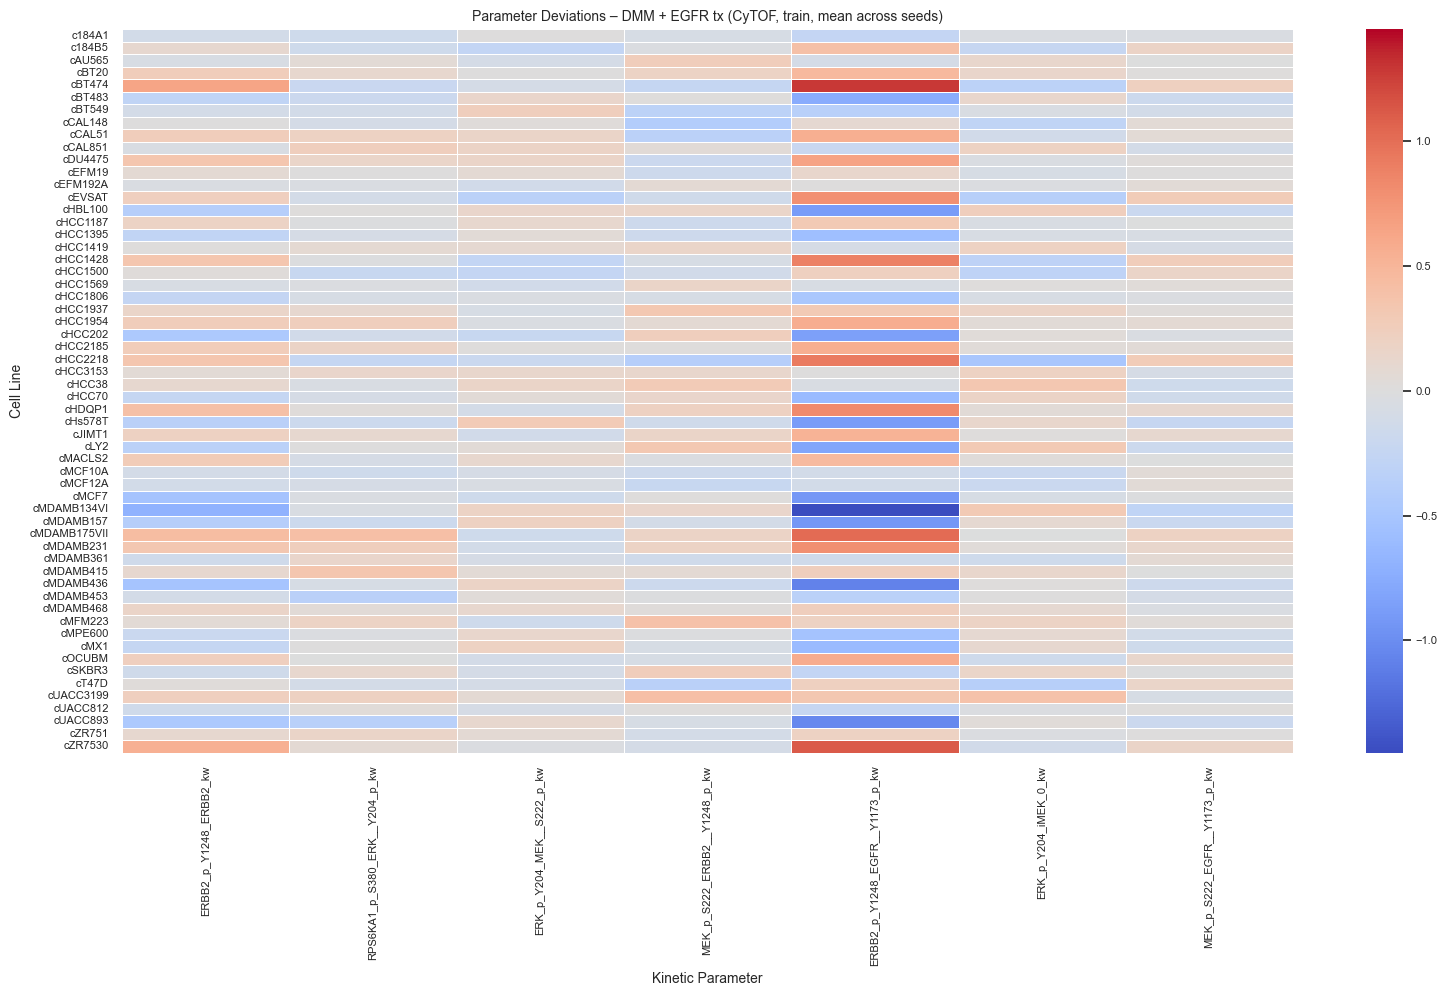

In [59]:
plot_param_deviation_heatmap(param_devs_df, context="cytof_init", dataset="train", param_order=param_order);

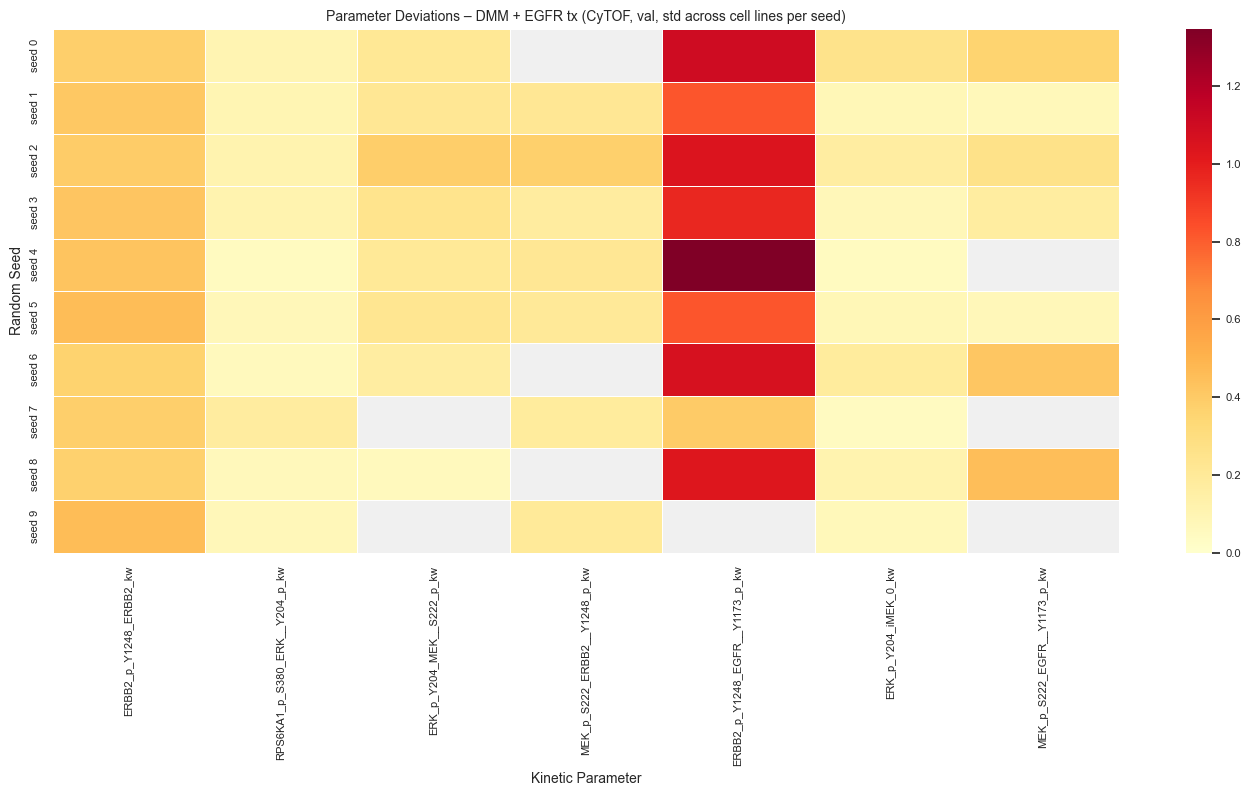

In [60]:
plot_param_deviation_heatmap(param_devs_df, context="cytof_init", dataset="val", per_seed=True, param_order=param_order, figsize=(14, 8));

## Parameter Deviation Correlations (Clustered)

Significant parameters: 7 / 44
Averaged across 10 seeds


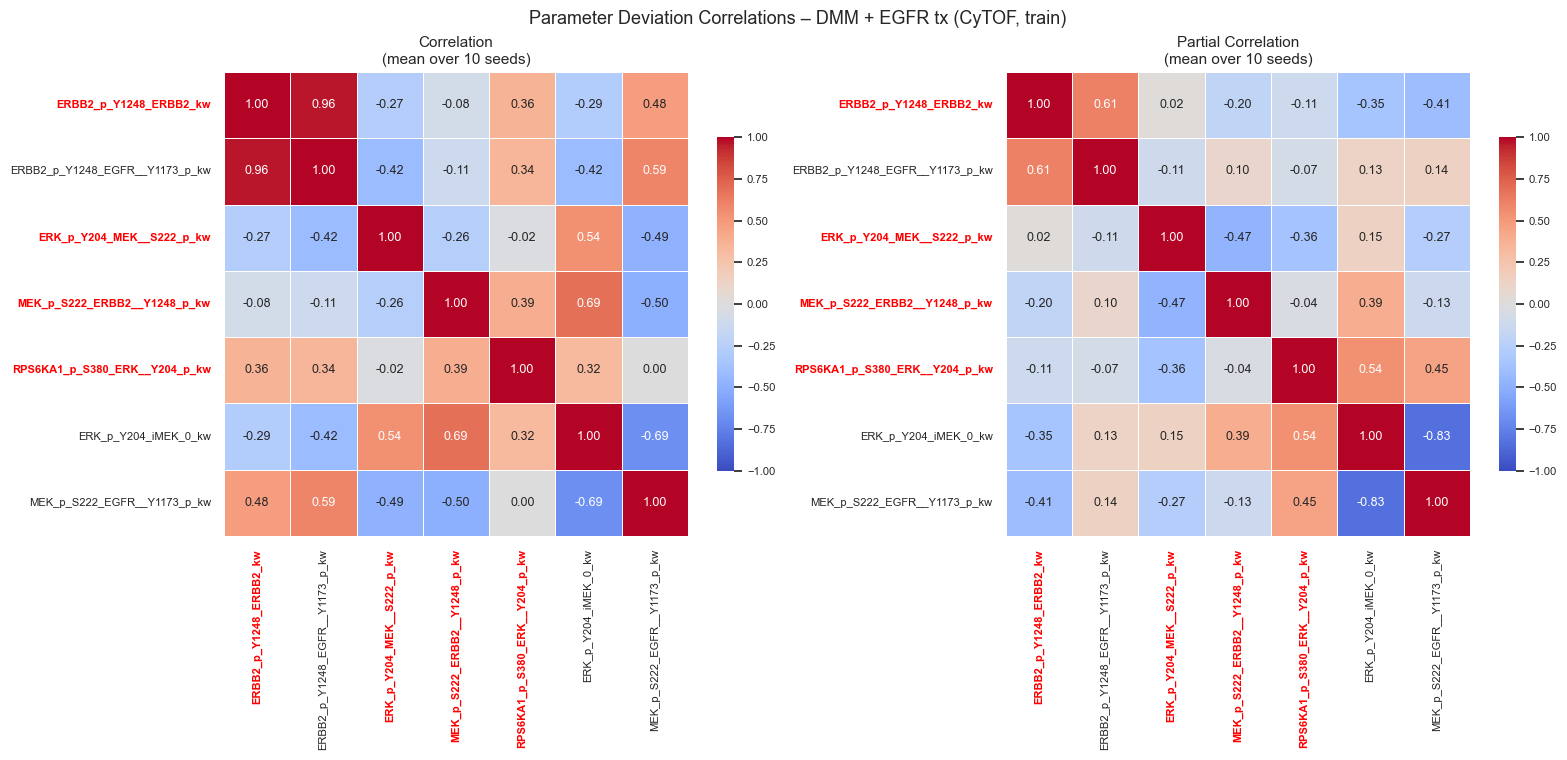

In [61]:
# Get all (cell_line, seed) deviations for cytof_init / train
subset = param_devs_df[
    (param_devs_df.context == "cytof_init") & (param_devs_df.dataset == "train")
]
param_cols = _get_param_columns(param_devs_df)

# Subset to statistically significant parameters only
sig_cols = [c for c in param_order if c in param_cols]


def _partial_corr(corr):
    """Compute partial correlation matrix from a correlation matrix.

    Partial correlations remove shared variance, revealing direct pairwise
    relationships that aren't mediated by other parameters.
    """
    try:
        prec = np.linalg.inv(corr)  # precision matrix
    except np.linalg.LinAlgError:
        prec = np.linalg.pinv(corr)
    d = np.sqrt(np.diag(prec))
    d[d == 0] = 1  # avoid division by zero
    pcorr = -prec / np.outer(d, d)
    np.fill_diagonal(pcorr, 1.0)
    return pcorr


# Compute correlation & partial correlation per seed, then average
seed_corrs = []
seed_pcorrs = []
for job, grp in subset.groupby("job"):
    dev_seed = grp.set_index("cell_line")[sig_cols]
    c = dev_seed.corr().values
    seed_corrs.append(c)
    seed_pcorrs.append(_partial_corr(c))

corr_mean = pd.DataFrame(np.nanmean(seed_corrs, axis=0), index=sig_cols, columns=sig_cols)
pcorr_mean = pd.DataFrame(np.nanmean(seed_pcorrs, axis=0), index=sig_cols, columns=sig_cols)

n_seeds = len(seed_corrs)
print(f"Significant parameters: {len(sig_cols)} / {len(param_cols)}")
print(f"Averaged across {n_seeds} seeds")

# --- Plot side by side: raw correlation vs partial correlation ---
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

# Cluster on partial correlations (the more informative structure)
dist = 1 - pcorr_mean.abs()
np.fill_diagonal(dist.values, 0)
condensed = squareform(dist.values, checks=False)
row_linkage = linkage(condensed, method="ward")

# Top 4 most sensitive parameters (by sensitivity ordering)
top4_sens = set(param_order[:4])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
context_label = CONTEXT_LABELS.get("cytof_init", "cytof_init")

# Reorder both matrices by the partial-corr clustering
from scipy.cluster.hierarchy import leaves_list
order_idx = leaves_list(row_linkage)
ordered_cols = [sig_cols[i] for i in order_idx]

for ax, mat, title_suffix in zip(
    axes,
    [corr_mean, pcorr_mean],
    ["Correlation", "Partial Correlation"],
):
    mat_ordered = mat.loc[ordered_cols, ordered_cols]
    sns.heatmap(
        mat_ordered,
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 9},
        linewidths=0.5, ax=ax, square=True,
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(f"{title_suffix}\n(mean over {n_seeds} seeds)", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Highlight top-4 most sensitive params in bold red
    for labels in [ax.get_xticklabels(), ax.get_yticklabels()]:
        for label in labels:
            if label.get_text() in top4_sens:
                label.set_color("red")
                label.set_fontweight("bold")

fig.suptitle(
    f"Parameter Deviation Correlations – {model_label} ({context_label}, train)",
    fontsize=13, y=1.02,
)
fig.tight_layout()
plt.show()

# PCA over Parameter Deviations – Low-Dimensional Subspace

PCA on the per-cell-line parameter deviations (significant parameters only) to
check whether a low-dimensional subspace captures most of the variation.
The hypothesis is that **~3 principal components** explain the bulk of the variance.

Auto-detected anchor parameters:
  SC1 → ERK_p_Y204_iMEK_0_kw (sign: +)
  SC2 → RPS6KA1_p_S380_ERK__Y204_p_kw (sign: +)
  SC3 → ERK_p_Y204_MEK__S222_p_kw (sign: +)
  SC4 → ERBB2_p_Y1248_ERBB2_kw (sign: +)
Saved seed-specific loadings to: /Users/frohlif/Documents/projects/DeepMechanisticModels/figures_paper/.cache/sensitive_loadings_per_seed_EGFR_MAPK__logobs_tegfr_aggavg_cytof_init_train.csv

Sparse PCA on 10 seeds × 7 parameters (alpha=1.0)
  SC1: 27.2% ± 6.9% variance, non-zero loadings: 2.3/7
  SC2: 17.7% ± 3.4% variance, non-zero loadings: 1.5/7
  SC3: 20.3% ± 11.7% variance, non-zero loadings: 2.3/7
  SC4: 34.4% ± 7.0% variance, non-zero loadings: 2.6/7
  Joint 3D subspace: 94.6% ± 8.8%


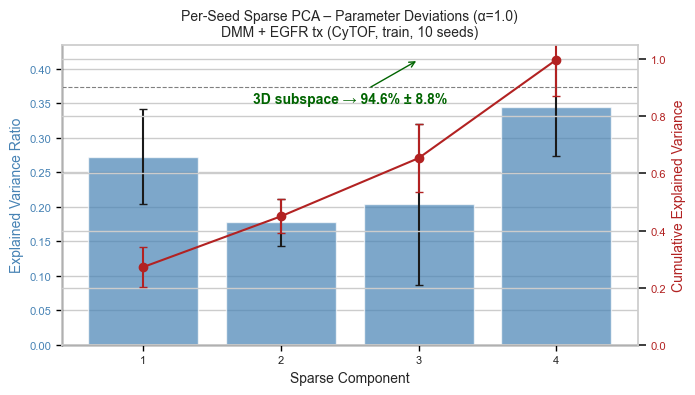

In [28]:
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import StandardScaler

# Build the deviation matrix: rows = (cell_line, seed), columns = significant params
subset_pca = param_devs_df[
    (param_devs_df.context == "cytof_init") & (param_devs_df.dataset == "train")
].copy()

param_cols_sig = [c for c in param_order if c in _get_param_columns(param_devs_df)]
N_PCS = 4  # number of components to retain

# --------------------------------------------------------------------------
# Sparse PCA
# --------------------------------------------------------------------------
# Sparse PCA applies an L1 penalty on the loadings, pushing small entries
# towards zero. This gives each component a clear parameter identity without
# manual anchoring or ad-hoc alignment heuristics.
#
# We still need to align components across seeds (permute + sign-flip) because
# SparsePCA does not guarantee a canonical ordering. We anchor each component
# to the parameter with the strongest mean loading from a first pass.
# --------------------------------------------------------------------------

SPCA_ALPHA = 1.0  # L1 penalty (higher → sparser); tune if needed

param_idx = {p: i for i, p in enumerate(param_cols_sig)}


def _align_components_by_anchor(components, param_idx, anchors, signs):
    """Align Sparse PCA components by anchoring each PC to a specific parameter."""
    n_pcs = len(anchors)
    aligned = np.zeros_like(components[:n_pcs])
    used = set()
    perm = []
    for target_pc in range(n_pcs):
        anchor_col = param_idx[anchors[target_pc]]
        anchor_loads = components[:, anchor_col].copy()
        for u in used:
            anchor_loads[u] = 0.0
        best = int(np.argmax(np.abs(anchor_loads)))
        sign = signs[target_pc] * np.sign(components[best, anchor_col])
        aligned[target_pc] = sign * components[best]
        used.add(best)
        perm.append(best)
    return aligned, perm


# --- First pass: fit Sparse PCA per seed, discover anchor params ---
seed_scalers = {}
raw_components = {}  # {job: (n_pcs, n_params)}

for job, grp in subset_pca.groupby("job"):
    X_seed = grp.set_index("cell_line")[param_cols_sig]
    sc = StandardScaler()
    X_s = sc.fit_transform(X_seed.values)
    spca = SparsePCA(n_components=N_PCS, alpha=SPCA_ALPHA, random_state=42,
                     max_iter=500)
    spca.fit(X_s)
    seed_scalers[job] = sc
    raw_components[job] = spca.components_.copy()  # (n_pcs, n_params)

# Determine anchor parameters from the pooled mean |loading| per component
# First do a rough alignment to seed 0 using cosine similarity
ref_job = sorted(raw_components.keys())[0]
ref_comp = raw_components[ref_job]

rough_aligned = {}
for job in raw_components:
    if job == ref_job:
        rough_aligned[job] = ref_comp.copy()
        continue
    comps = raw_components[job]
    n = N_PCS
    aligned = np.zeros_like(comps[:n])
    used = set()
    for i in range(n):
        sims = np.array([np.dot(ref_comp[i], comps[j]) for j in range(n)])
        for u in used:
            sims[u] = 0.0
        best = int(np.argmax(np.abs(sims)))
        aligned[i] = np.sign(sims[best]) * comps[best]
        used.add(best)
    rough_aligned[job] = aligned

rough_stack = np.stack(list(rough_aligned.values()))  # (n_seeds, n_pcs, n_params)
rough_mean = np.abs(rough_stack).mean(axis=0)  # (n_pcs, n_params)

# For each PC, pick the parameter with the largest mean |loading| as anchor
ANCHOR_PARAMS = {}
ANCHOR_SIGNS = {}
used_params = set()
for pc_i in range(N_PCS):
    loads = rough_mean[pc_i].copy()
    # mask already-used anchors
    for p in used_params:
        loads[param_idx[p]] = 0.0
    best_param_idx = int(np.argmax(loads))
    best_param = param_cols_sig[best_param_idx]
    ANCHOR_PARAMS[pc_i] = best_param
    # sign: use the sign from the rough mean
    mean_signed = rough_stack[:, pc_i, best_param_idx].mean()
    ANCHOR_SIGNS[pc_i] = +1 if mean_signed >= 0 else -1
    used_params.add(best_param)

print("Auto-detected anchor parameters:")
for pc_i in range(N_PCS):
    sign_str = "+" if ANCHOR_SIGNS[pc_i] > 0 else "−"
    print(f"  SC{pc_i+1} → {ANCHOR_PARAMS[pc_i]} (sign: {sign_str})")

# --- Second pass: align all seeds using discovered anchors ---
seed_components = {}

for job in raw_components:
    aligned, perm = _align_components_by_anchor(
        raw_components[job], param_idx, ANCHOR_PARAMS, ANCHOR_SIGNS,
    )
    seed_components[job] = aligned

# Compute mean and std of aligned loadings across seeds
all_loadings = np.stack(list(seed_components.values()))  # (n_seeds, n_pcs, n_params)
mean_loadings = all_loadings.mean(axis=0)                # (n_pcs, n_params)
std_loadings = all_loadings.std(axis=0)

n_seeds = len(seed_components)
n_params = len(param_cols_sig)

# --- Persist seed-specific sparse-PCA loadings for downstream reuse ---
direction_labels = [f"D{i+1}" for i in range(N_PCS)]
seed_loading_rows = []
for job, comps in seed_components.items():
    for pc_i, direction in enumerate(direction_labels):
        for param_i, parameter in enumerate(param_cols_sig):
            seed_loading_rows.append(
                {
                    "model": MODEL,
                    "context": "cytof_init",
                    "dataset": "train",
                    "direction": direction,
                    "seed": str(job),
                    "parameter": parameter,
                    "loading": float(comps[pc_i, param_i]),
                }
            )

sensitive_loadings_per_seed_df = pd.DataFrame(seed_loading_rows)
sensitive_loadings_mean_df = (
    sensitive_loadings_per_seed_df
    .groupby(["direction", "parameter"], as_index=False)["loading"]
    .mean()
)

cache_dir = basedir / "figures_paper" / ".cache"
cache_dir.mkdir(exist_ok=True)
loadings_cache_file = cache_dir / f"sensitive_loadings_per_seed_{MODEL}_cytof_init_train.csv"
sensitive_loadings_per_seed_df.to_csv(loadings_cache_file, index=False)
print(f"Saved seed-specific loadings to: {loadings_cache_file}")

# --- Explained variance: for each component, variance of scores / total ---
# Sparse PCA components are not orthonormal, so we compute explained variance
# per component as Var(X @ v_hat) / Var_total, where v_hat is the unit-length
# direction of the component.  Individual values may overlap (not additive).
# We also report the joint explained variance from the 3D projection.
seed_explained = {}
seed_explained_joint = {}
for job, grp in subset_pca.groupby("job"):
    X_seed = grp.set_index("cell_line")[param_cols_sig]
    X_s = seed_scalers[job].transform(X_seed.values)
    total_var = np.sum(X_s ** 2)
    comps = seed_components[job]  # (n_pcs, n_params)
    explained = np.zeros(N_PCS)
    for k in range(N_PCS):
        v = comps[k]
        nrm = np.linalg.norm(v)
        if nrm > 0:
            v_hat = v / nrm
            scores_k = X_s @ v_hat  # (n_cells,)
            explained[k] = np.sum(scores_k ** 2) / total_var
    seed_explained[job] = explained
    # Joint: project onto the subspace spanned by all 3 components (QR basis)
    Q, _ = np.linalg.qr(comps.T)  # (n_params, n_pcs) orthonormal basis
    proj_joint = X_s @ Q  # (n_cells, n_pcs)
    seed_explained_joint[job] = np.sum(proj_joint ** 2) / total_var

all_explained = np.stack(list(seed_explained.values()))   # (n_seeds, n_pcs)
mean_explained = all_explained.mean(axis=0)
std_explained = all_explained.std(axis=0)

all_joint = np.array(list(seed_explained_joint.values()))  # (n_seeds,)
mean_joint = all_joint.mean()
std_joint = all_joint.std()

# Sparsity summary
n_nonzero = (np.abs(all_loadings) > 1e-6).sum(axis=2)  # (n_seeds, n_pcs)
mean_nnz = n_nonzero.mean(axis=0)

print(f"\nSparse PCA on {n_seeds} seeds × {n_params} parameters (alpha={SPCA_ALPHA})")
for i in range(N_PCS):
    print(f"  SC{i+1}: {mean_explained[i]:.1%} ± {std_explained[i]:.1%} variance, "
          f"non-zero loadings: {mean_nnz[i]:.1f}/{n_params}")
print(f"  Joint 3D subspace: {mean_joint:.1%} ± {std_joint:.1%}")

# --- Scree plot: per-seed explained variance ---
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.bar(range(1, N_PCS + 1), mean_explained, yerr=std_explained,
        color="steelblue", alpha=0.7, capsize=3)
ax1.set_xlabel("Sparse Component")
ax1.set_ylabel("Explained Variance Ratio", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(1, N_PCS + 1))

ax2 = ax1.twinx()
cumvar_per_seed = np.cumsum(all_explained, axis=1)
mean_cumvar = cumvar_per_seed.mean(axis=0)
std_cumvar = cumvar_per_seed.std(axis=0)
pcs = range(1, N_PCS + 1)
ax2.errorbar(pcs, mean_cumvar, yerr=std_cumvar, fmt="o-", color="firebrick",
             capsize=3, label="Cumulative (mean ± sd)")
ax2.set_ylabel("Cumulative Explained Variance", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.axhline(0.9, ls="--", color="gray", lw=0.8)
ax2.set_ylim(0, 1.05)

ax2.annotate(f"3D subspace → {mean_joint:.1%} ± {std_joint:.1%}",
             xy=(3, mean_cumvar[-1]),
             xytext=(1.8, mean_cumvar[-1] - 0.15),
             arrowprops=dict(arrowstyle="->", color="darkgreen"),
             fontsize=10, color="darkgreen", fontweight="bold")

context_label = CONTEXT_LABELS.get("cytof_init", "cytof_init")
ax1.set_title(f"Per-Seed Sparse PCA – Parameter Deviations (α={SPCA_ALPHA})\n"
              f"{model_label} ({context_label}, train, {n_seeds} seeds)")
configure_axis_spines(ax1)
fig.tight_layout()
plt.show()

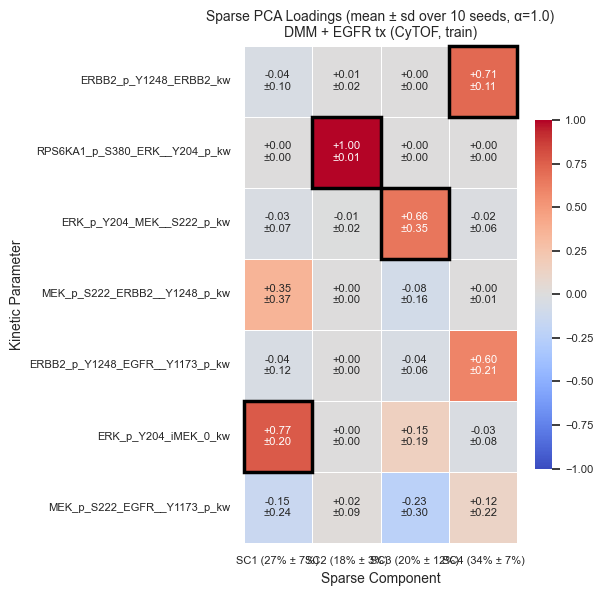

In [29]:
# --- Loadings heatmap: mean ± sd across seeds (Sparse PCA) ---
loadings_df = pd.DataFrame(
    mean_loadings.T,
    index=param_cols_sig,
    columns=[f"SC{i+1} ({mean_explained[i]:.0%} ± {std_explained[i]:.0%})"
             for i in range(N_PCS)],
)

# Annotation: "mean (±sd)"
annot_strings = np.empty_like(mean_loadings.T, dtype=object)
for i in range(n_params):
    for j in range(N_PCS):
        m = mean_loadings[j, i]
        s = std_loadings[j, i]
        annot_strings[i, j] = f"{m:+.2f}\n±{s:.2f}"

fig, ax = plt.subplots(figsize=(6, max(6, 0.55 * n_params)))
sns.heatmap(
    loadings_df, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=annot_strings, fmt="",
    annot_kws={"size": 8},
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.7},
)

# Highlight anchor cells with a thick border
for pc_i in range(N_PCS):
    row = param_cols_sig.index(ANCHOR_PARAMS[pc_i])
    ax.add_patch(plt.Rectangle((pc_i, row), 1, 1, fill=False,
                                edgecolor="black", lw=2.5, clip_on=False))

ax.set_title(f"Sparse PCA Loadings (mean ± sd over {n_seeds} seeds, α={SPCA_ALPHA})\n"
             f"{model_label} ({context_label}, train)")
ax.set_xlabel("Sparse Component")
ax.set_ylabel("Kinetic Parameter")
fig.tight_layout()
plt.show()

## PCA-Derived Sensitivity Directions

Use the 3 PCA loadings vectors to define **data-driven sensitivity directions** in
the parameter space. Each direction is a weighted combination of all 7 significant
parameters — unlike the hand-picked `sensitive_dirs` which group parameters by
prior knowledge.

For each cell line, the PCA score along a direction gives a single number summarising
its position along that axis of variation.

In [30]:
# --- Define PCA-derived sensitivity directions from mean aligned loadings ---
pc_labels = ["PC1", "PC2", "PC3", "PC4"]
pca_directions = {}
for i, label in enumerate(pc_labels):
    weights = dict(zip(param_cols_sig, mean_loadings[i]))
    pca_directions[label] = weights

# Print the directions with dominant contributors
print("PCA-derived sensitivity directions (mean aligned loadings):\n")
for label, weights in pca_directions.items():
    i = int(label[-1]) - 1
    print(f"  {label} ({mean_explained[i]:.1%} ± {std_explained[i]:.1%} variance):")
    sorted_w = sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)
    for param, w in sorted_w:
        bar = "█" * int(abs(w) * 20)
        sign = "+" if w > 0 else "−"
        print(f"    {sign}{abs(w):.3f}  {param}  {bar}")
    print()

# Compare with existing hand-picked sensitive_dirs
from figures_paper.embeddings import sensitive_dirs

print("=" * 70)
print("Comparison with hand-picked sensitive_dirs:\n")
for dir_name, params in sensitive_dirs.items():
    print(f"  {dir_name}: {params}")
    for pc_label in pc_labels:
        i = int(pc_label[-1]) - 1
        group_vec = np.array([1.0 if p in params else 0.0 for p in param_cols_sig])
        if np.linalg.norm(group_vec) > 0:
            group_vec = group_vec / np.linalg.norm(group_vec)
        alignment = np.dot(group_vec, mean_loadings[i])
        print(f"    cos({dir_name}, {pc_label}) = {alignment:+.3f}")
    print()

PCA-derived sensitivity directions (mean aligned loadings):

  PC1 (27.2% ± 6.9% variance):
    +0.766  ERK_p_Y204_iMEK_0_kw  ███████████████
    +0.353  MEK_p_S222_ERBB2__Y1248_p_kw  ███████
    −0.147  MEK_p_S222_EGFR__Y1173_p_kw  ██
    −0.044  ERBB2_p_Y1248_ERBB2_kw  
    −0.039  ERBB2_p_Y1248_EGFR__Y1173_p_kw  
    −0.032  ERK_p_Y204_MEK__S222_p_kw  
    −0.000  RPS6KA1_p_S380_ERK__Y204_p_kw  

  PC2 (17.7% ± 3.4% variance):
    +0.995  RPS6KA1_p_S380_ERK__Y204_p_kw  ███████████████████
    +0.020  MEK_p_S222_EGFR__Y1173_p_kw  
    −0.006  ERK_p_Y204_MEK__S222_p_kw  
    +0.005  ERBB2_p_Y1248_ERBB2_kw  
    −0.000  MEK_p_S222_ERBB2__Y1248_p_kw  
    −0.000  ERBB2_p_Y1248_EGFR__Y1173_p_kw  
    −0.000  ERK_p_Y204_iMEK_0_kw  

  PC3 (20.3% ± 11.7% variance):
    +0.661  ERK_p_Y204_MEK__S222_p_kw  █████████████
    −0.232  MEK_p_S222_EGFR__Y1173_p_kw  ████
    +0.149  ERK_p_Y204_iMEK_0_kw  ██
    −0.079  MEK_p_S222_ERBB2__Y1248_p_kw  █
    −0.041  ERBB2_p_Y1248_EGFR__Y1173_p_kw  
   

In [31]:
# --- Per-cell-line PCA scores using per-seed loadings ---
# For each seed: standardise deviations with that seed's scaler, project
# onto that seed's aligned PCA components → per-seed scores.
# Then average scores across seeds for each cell line.

from figures_paper.embeddings import (
    load_embedding_data,
    load_marcotte_subtypes,
    prepare_pca_embeddings,
    load_parameter_data,
)

all_seed_scores = []
for job, grp in subset_pca.groupby("job"):
    X_seed = grp.set_index("cell_line")[param_cols_sig]
    X_s = seed_scalers[job].transform(X_seed.values)
    # Project onto aligned components for this seed
    scores_seed = X_s @ seed_components[job].T  # (n_cells, 3)
    df_scores = pd.DataFrame(scores_seed, index=X_seed.index, columns=pc_labels)
    df_scores["seed"] = job
    all_seed_scores.append(df_scores)

all_seed_scores_df = pd.concat(all_seed_scores)

# Average across seeds
cell_pca_scores = (
    all_seed_scores_df.groupby(level=0)[pc_labels].mean()
)

# Also keep per-seed version for later use
cell_pca_scores_per_seed = all_seed_scores_df.copy()

# --- Load embeddings ---
embedding_df = load_embedding_data(figure=FIGURE)
subtypes_df = load_marcotte_subtypes(embedding_df.cell_line.unique())
pca_embedding_df = prepare_pca_embeddings(embedding_df, subtypes_df)

emb_df = pca_embedding_df[
    (pca_embedding_df["model"] == MODEL)
    & (pca_embedding_df["context"] == "cytof_init")
].copy()
embedding_cols = [c for c in emb_df.columns if c.startswith("L")]

# Merge mean PCA scores with embeddings
common = cell_pca_scores.index.intersection(emb_df.index)
merged = emb_df.loc[common, embedding_cols].join(cell_pca_scores.loc[common])

print(f"Cell lines with both embeddings and PCA scores: {len(common)}")
print(f"Per-seed scores: {len(all_seed_scores_df)} rows "
      f"({all_seed_scores_df.index.nunique()} cell lines × {n_seeds} seeds)")
print(f"\nMean PCA scores summary (averaged over {n_seeds} seeds):")
display(cell_pca_scores.describe().round(2))

Cell lines with both embeddings and PCA scores: 58
Per-seed scores: 580 rows (58 cell lines × 10 seeds)

Mean PCA scores summary (averaged over 10 seeds):


,PC1,PC2,PC3,PC4
count,58.00,58.00,58.00,58.00
mean,-0.00,0.00,-0.00,0.00
std,1.13,1.01,0.88,1.42
min,-2.93,-2.24,-2.07,-3.38
25%,-0.80,-0.64,-0.71,-1.01
50%,0.13,-0.09,0.05,0.10
75%,0.77,0.74,0.66,1.14
max,2.38,2.59,1.63,2.98


Top-4 sensitive parameters: ['ERBB2_p_Y1248_ERBB2_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERK_p_Y204_MEK__S222_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw']


Seeds processed: 10

Per-seed embedding PC labels (strongest association among top-4 params):


,seed,n_cell_lines,PC1_label,PC1_rho,PC2_label,PC2_rho,PC3_label,PC3_rho,PC4_label,PC4_rho
0,0,58,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.860592,ERK_p_Y204_MEK__S222_p_kw,0.855486,ERBB2_p_Y1248_ERBB2_kw,0.754591,ERK_p_Y204_MEK__S222_p_kw,0.224215
1,1,58,RPS6KA1_p_S380_ERK__Y204_p_kw,0.875604,ERBB2_p_Y1248_ERBB2_kw,0.724692,ERK_p_Y204_MEK__S222_p_kw,-0.919530,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.400166
2,2,58,RPS6KA1_p_S380_ERK__Y204_p_kw,0.789228,ERK_p_Y204_MEK__S222_p_kw,-0.939217,ERBB2_p_Y1248_ERBB2_kw,0.645575,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.423667
3,3,58,MEK_p_S222_ERBB2__Y1248_p_kw,-0.844166,ERBB2_p_Y1248_ERBB2_kw,-0.834138,ERK_p_Y204_MEK__S222_p_kw,0.705435,RPS6KA1_p_S380_ERK__Y204_p_kw,0.562029
4,4,58,MEK_p_S222_ERBB2__Y1248_p_kw,0.679966,MEK_p_S222_ERBB2__Y1248_p_kw,-0.698299,ERK_p_Y204_MEK__S222_p_kw,0.942047,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.597035
5,5,58,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.830693,ERBB2_p_Y1248_ERBB2_kw,0.946415,ERK_p_Y204_MEK__S222_p_kw,0.840044,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.348734
6,6,58,RPS6KA1_p_S380_ERK__Y204_p_kw,0.790643,ERBB2_p_Y1248_ERBB2_kw,0.890123,ERK_p_Y204_MEK__S222_p_kw,0.776185,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.517672
7,7,58,RPS6KA1_p_S380_ERK__Y204_p_kw,0.892953,MEK_p_S222_ERBB2__Y1248_p_kw,0.719893,MEK_p_S222_ERBB2__Y1248_p_kw,-0.564059,MEK_p_S222_ERBB2__Y1248_p_kw,-0.388785
8,8,58,ERK_p_Y204_MEK__S222_p_kw,-0.839060,ERBB2_p_Y1248_ERBB2_kw,0.924513,RPS6KA1_p_S380_ERK__Y204_p_kw,0.354517,ERK_p_Y204_MEK__S222_p_kw,0.382633
9,9,58,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.882617,MEK_p_S222_ERBB2__Y1248_p_kw,0.803378,ERBB2_p_Y1248_ERBB2_kw,-0.797841,MEK_p_S222_ERBB2__Y1248_p_kw,0.536682



Consensus labels across seeds (counts):


,pc,parameter,n_seeds
2,PC1,RPS6KA1_p_S380_ERK__Y204_p_kw,7
1,PC1,MEK_p_S222_ERBB2__Y1248_p_kw,2
0,PC1,ERK_p_Y204_MEK__S222_p_kw,1
3,PC2,ERBB2_p_Y1248_ERBB2_kw,5
5,PC2,MEK_p_S222_ERBB2__Y1248_p_kw,3
4,PC2,ERK_p_Y204_MEK__S222_p_kw,2
7,PC3,ERK_p_Y204_MEK__S222_p_kw,5
6,PC3,ERBB2_p_Y1248_ERBB2_kw,3
8,PC3,MEK_p_S222_ERBB2__Y1248_p_kw,1
9,PC3,RPS6KA1_p_S380_ERK__Y204_p_kw,1


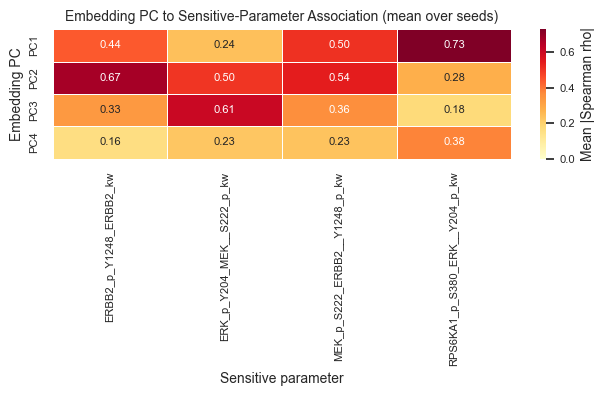

In [32]:
# --- Per-seed embedding PCA labeling by top-4 sensitive parameters ---
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from training_configuration import LATENT_DIMS, NETWORK_DEPTH
from figures_paper.embeddings import load_embedding_data

MODEL_ = globals().get("MODEL", "EGFR_MAPK__logobs_tegfr_aggavg")
DATASET_ = globals().get("DATASET", "dream_cytof")
FIGURE_ = globals().get("FIGURE", "figure3")

if "params_df" not in globals():
    params_df = load_sensitivity_data("params", model=MODEL_, dataset=DATASET_, figure=FIGURE_)
if "param_order" not in globals():
    param_order = get_param_sensitivity_order(params_df, context="cytof_init", dataset="train")
if "param_devs_df" not in globals():
    param_devs_df = load_param_devs(model=MODEL_, dataset=DATASET_, figure=FIGURE_)

# Top-4 sensitive parameters from train sensitivity ranking
top4_sensitive = [p for p in param_order[:4] if p in param_devs_df.columns]
if len(top4_sensitive) < 4:
    print(f"Warning: only {len(top4_sensitive)} of top-4 sensitive parameters found in param_devs.")
print("Top-4 sensitive parameters:", top4_sensitive)

# Parameter deviations per seed and cell line (train/cytof_init)
param_seed_df = (
    param_devs_df[
        (param_devs_df["context"] == "cytof_init")
        & (param_devs_df["dataset"] == "train")
    ][["job", "cell_line"] + top4_sensitive]
    .groupby(["job", "cell_line"], as_index=False)
    .mean()
)
param_seed_df["job"] = param_seed_df["job"].astype(str)

# Raw embeddings (not PCA-reduced) per seed and cell line
embedding_raw = load_embedding_data(figure=FIGURE_, data=DATASET_)
embedding_raw = embedding_raw[
    (embedding_raw["model"] == MODEL_)
    & (embedding_raw["context"] == "cytof_init")
    & (embedding_raw["depth"] == NETWORK_DEPTH["central_value"])
    & (embedding_raw["n_hidden"] == LATENT_DIMS["central_value"])
    & (embedding_raw["samples"].str.startswith("all"))
].copy()

latent_cols = [c for c in embedding_raw.columns if c.startswith("L")]
embedding_raw["job"] = embedding_raw["job"].astype(str)

# Use up to 3 embedding PCs (or fewer if dimensions/samples are limited)
n_pcs_embed = min(4, len(latent_cols))

rows = []
assoc_rows = []
common_jobs = sorted(set(embedding_raw["job"]).intersection(set(param_seed_df["job"])))

for job in common_jobs:
    emb_j = embedding_raw[embedding_raw["job"] == job].set_index("cell_line")
    par_j = param_seed_df[param_seed_df["job"] == job].set_index("cell_line")
    common_cells = emb_j.index.intersection(par_j.index)

    if len(common_cells) < 4:
        continue

    X = emb_j.loc[common_cells, latent_cols].values
    Xs = StandardScaler().fit_transform(X)

    n_pcs_j = min(n_pcs_embed, Xs.shape[0], Xs.shape[1])
    if n_pcs_j < 1:
        continue

    pca_j = PCA(n_components=n_pcs_j)
    scores_j = pca_j.fit_transform(Xs)
    score_df = pd.DataFrame(scores_j, index=common_cells, columns=[f"PC{i+1}" for i in range(n_pcs_j)])

    row = {"seed": job, "n_cell_lines": len(common_cells)}
    for pc_i in range(n_pcs_j):
        pc_name = f"PC{pc_i+1}"
        best_param = None
        best_rho = np.nan

        for param in top4_sensitive:
            rho, _ = spearmanr(score_df[pc_name], par_j.loc[common_cells, param])
            if np.isnan(best_rho) or abs(rho) > abs(best_rho):
                best_rho = rho
                best_param = param
            assoc_rows.append({
                "seed": job,
                "pc": pc_name,
                "parameter": param,
                "rho": rho,
                "abs_rho": abs(rho) if pd.notna(rho) else np.nan,
            })

        row[f"{pc_name}_label"] = best_param
        row[f"{pc_name}_rho"] = best_rho

    rows.append(row)

seed_pc_labels_df = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)
seed_pc_assoc_df = pd.DataFrame(assoc_rows)

print(f"Seeds processed: {len(seed_pc_labels_df)}")
print("\nPer-seed embedding PC labels (strongest association among top-4 params):")
display(seed_pc_labels_df)

if not seed_pc_assoc_df.empty:
    consensus = (
        seed_pc_assoc_df.loc[
            seed_pc_assoc_df.groupby(["seed", "pc"])["abs_rho"].idxmax()
        ]
        .groupby(["pc", "parameter"])
        .size()
        .rename("n_seeds")
        .reset_index()
        .sort_values(["pc", "n_seeds"], ascending=[True, False])
    )

    print("\nConsensus labels across seeds (counts):")
    display(consensus)

    # Optional diagnostic heatmap: mean absolute association for each PC/parameter
    mean_abs_assoc = (
        seed_pc_assoc_df
        .groupby(["pc", "parameter"])["abs_rho"]
        .mean()
        .unstack("parameter")
        .reindex(index=[f"PC{i+1}" for i in range(n_pcs_embed)])
    )

    fig, ax = plt.subplots(figsize=(1.6 * max(4, len(top4_sensitive)), 4))
    sns.heatmap(
        mean_abs_assoc,
        cmap="YlOrRd",
        vmin=0,
        vmax=np.nanmax(mean_abs_assoc.values),
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"label": "Mean |Spearman rho|"},
        ax=ax,
    )
    ax.set_title("Embedding PC to Sensitive-Parameter Association (mean over seeds)")
    ax.set_xlabel("Sensitive parameter")
    ax.set_ylabel("Embedding PC")
    fig.tight_layout()
    plt.show()

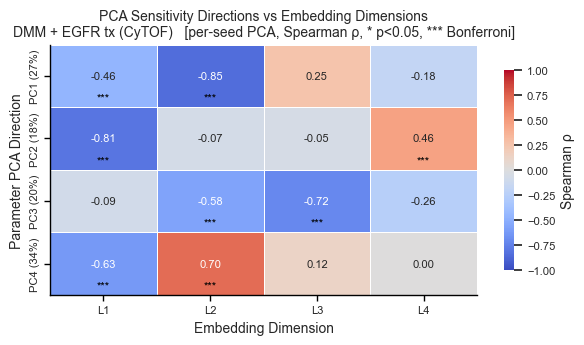


Strongest associations (|ρ| > 0.3):
  PC1 (27%) ↔ L1: ρ = -0.463 ***
  PC1 (27%) ↔ L2: ρ = -0.848 ***
  PC2 (18%) ↔ L1: ρ = -0.808 ***
  PC2 (18%) ↔ L4: ρ = +0.459 ***
  PC3 (20%) ↔ L2: ρ = -0.576 ***
  PC3 (20%) ↔ L3: ρ = -0.716 ***
  PC4 (34%) ↔ L1: ρ = -0.632 ***
  PC4 (34%) ↔ L2: ρ = +0.702 ***


In [34]:
# --- Correlation between PCA directions and embedding dimensions ---
from scipy.stats import spearmanr

n_emb = len(embedding_cols)
corr_matrix = np.zeros((N_PCS, n_emb))
pval_matrix = np.zeros((N_PCS, n_emb))

for i, pc in enumerate(pc_labels):
    for j, emb_col in enumerate(embedding_cols):
        rho, pv = spearmanr(merged[pc], merged[emb_col])
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pv

corr_df = pd.DataFrame(
    corr_matrix,
    index=[f"PC{i+1} ({mean_explained[i]:.0%})" for i in range(N_PCS)],
    columns=embedding_cols,
)

fig, ax = plt.subplots(figsize=(max(6, 0.9 * n_emb), 3.5))
sns.heatmap(
    corr_df, cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
)

n_tests = N_PCS * n_emb
for i in range(N_PCS):
    for j in range(n_emb):
        if pval_matrix[i, j] < 0.05 / n_tests:
            ax.text(j + 0.5, i + 0.85, "***", ha="center", va="center", fontsize=8, color="black")
        elif pval_matrix[i, j] < 0.05:
            ax.text(j + 0.5, i + 0.85, "*", ha="center", va="center", fontsize=8, color="black")

ax.set_title(
    f"PCA Sensitivity Directions vs Embedding Dimensions\n"
    f"{model_label} ({context_label})   [per-seed PCA, Spearman ρ, * p<0.05, *** Bonferroni]"
)
ax.set_ylabel("Parameter PCA Direction")
ax.set_xlabel("Embedding Dimension")
configure_axis_spines(ax)
fig.tight_layout()
plt.show()

print("\nStrongest associations (|ρ| > 0.3):")
for i, pc in enumerate(corr_df.index):
    for j, emb in enumerate(corr_df.columns):
        rho = corr_df.iloc[i, j]
        if abs(rho) > 0.3:
            sig = "***" if pval_matrix[i, j] < 0.05 / n_tests else ("*" if pval_matrix[i, j] < 0.05 else "")
            print(f"  {pc} ↔ {emb}: ρ = {rho:+.3f} {sig}")

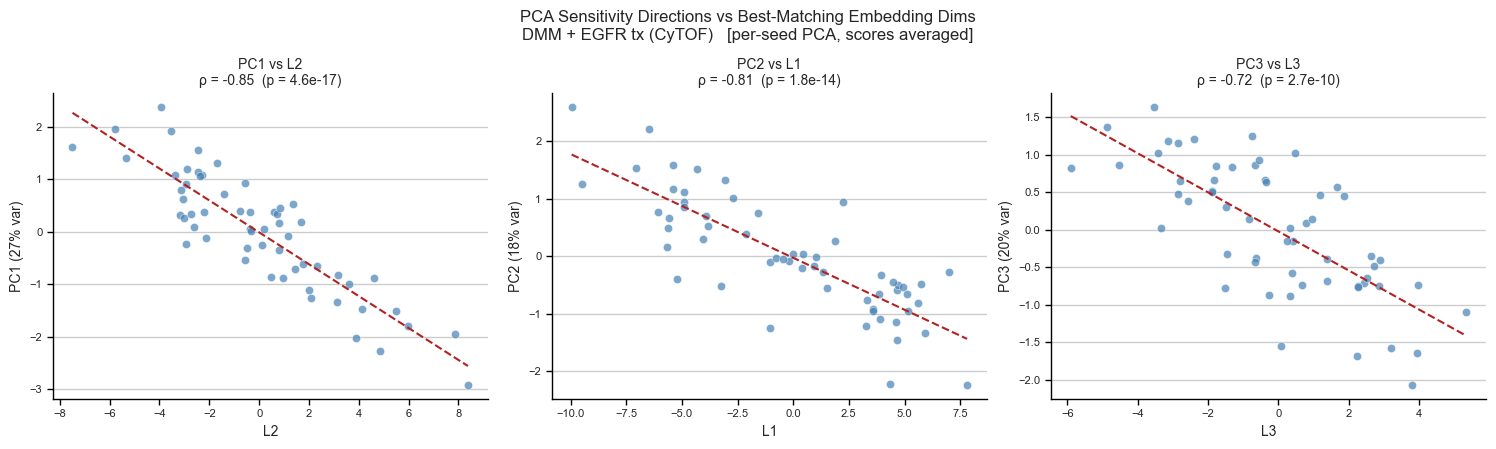

In [35]:
# --- Scatter plots: each PCA direction vs its best-correlated embedding dim ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, (pc, ax) in enumerate(zip(pc_labels, axes)):
    best_j = int(np.argmax(np.abs(corr_matrix[i])))
    best_emb = embedding_cols[best_j]
    rho = corr_matrix[i, best_j]
    pv = pval_matrix[i, best_j]

    ax.scatter(merged[best_emb], merged[pc], s=35, alpha=0.7,
               color="steelblue", edgecolors="white", linewidth=0.4)

    z = np.polyfit(merged[best_emb], merged[pc], 1)
    x_line = np.linspace(merged[best_emb].min(), merged[best_emb].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), "--", color="firebrick", lw=1.5)

    ax.set_xlabel(best_emb)
    ax.set_ylabel(f"{pc} ({mean_explained[i]:.0%} var)")
    ax.set_title(f"{pc} vs {best_emb}\nρ = {rho:+.2f}  (p = {pv:.1e})")
    configure_axis_spines(ax)

fig.suptitle(
    f"PCA Sensitivity Directions vs Best-Matching Embedding Dims\n"
    f"{model_label} ({context_label})   [per-seed PCA, scores averaged]",
    fontsize=12,
)
fig.tight_layout()
plt.show()

In [36]:
# --- Export: PCA directions as weighted parameter groups ---
# Uses seed-specific loadings (sensitive_loadings_per_seed_df) and mean loadings.

print("# PCA-derived sensitivity directions for embeddings.py")
print("# (mean aligned loadings over", n_seeds, "seeds, cytof_init/train)\n")
print("sensitive_dirs_pca = {")
for i in range(N_PCS):
    direction = f"D{i+1}"
    var = mean_explained[i]
    weights = mean_loadings[i]
    top = [(p, w) for p, w in zip(param_cols_sig, weights) if abs(w) > 0.2]
    top.sort(key=lambda x: abs(x[1]), reverse=True)
    top_names = [p for p, _ in top]
    print(f'    "{direction}": {tuple(top_names)},  # {var:.1%} var, top |loading| > 0.2')
print("}")

print("\n\n# Full mean loading vectors:")
print("sensitive_loadings_pca = {")
for i in range(N_PCS):
    direction = f"D{i+1}"
    weights = {p: round(float(w), 4) for p, w in zip(param_cols_sig, mean_loadings[i])}
    print(f'    "{direction}": {weights},')
print("}")

print("\nSeed-specific loadings DataFrame head:")
display(sensitive_loadings_per_seed_df.head())

print(f"\nReusable seed-specific loadings cache: {loadings_cache_file}")

# PCA-derived sensitivity directions for embeddings.py
# (mean aligned loadings over 10 seeds, cytof_init/train)

sensitive_dirs_pca = {
    "D1": ('ERK_p_Y204_iMEK_0_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw'),  # 27.2% var, top |loading| > 0.2
    "D2": ('RPS6KA1_p_S380_ERK__Y204_p_kw',),  # 17.7% var, top |loading| > 0.2
    "D3": ('ERK_p_Y204_MEK__S222_p_kw', 'MEK_p_S222_EGFR__Y1173_p_kw'),  # 20.3% var, top |loading| > 0.2
    "D4": ('ERBB2_p_Y1248_ERBB2_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw'),  # 34.4% var, top |loading| > 0.2
}


# Full mean loading vectors:
sensitive_loadings_pca = {
    "D1": {'ERBB2_p_Y1248_ERBB2_kw': -0.0437, 'RPS6KA1_p_S380_ERK__Y204_p_kw': 0.0, 'ERK_p_Y204_MEK__S222_p_kw': -0.032, 'MEK_p_S222_ERBB2__Y1248_p_kw': 0.3532, 'ERBB2_p_Y1248_EGFR__Y1173_p_kw': -0.0394, 'ERK_p_Y204_iMEK_0_kw': 0.7662, 'MEK_p_S222_EGFR__Y1173_p_kw': -0.1466},
    "D2": {'ERBB2_p_Y1248_ERBB2_kw': 0.0051, 'RPS6KA1_p_S380_ERK__Y204_p_kw': 0.9951, 'ERK_p_Y204_MEK__S222_p_kw': -0.006, 'MEK_p_S2

,model,context,dataset,direction,seed,parameter,loading
0,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,train,D1,0,ERBB2_p_Y1248_ERBB2_kw,-0.130792
1,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,train,D1,0,RPS6KA1_p_S380_ERK__Y204_p_kw,-0.000000
2,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,train,D1,0,ERK_p_Y204_MEK__S222_p_kw,-0.000000
3,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,train,D1,0,MEK_p_S222_ERBB2__Y1248_p_kw,-0.000000
4,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,train,D1,0,ERBB2_p_Y1248_EGFR__Y1173_p_kw,-0.000000



Reusable seed-specific loadings cache: /Users/frohlif/Documents/projects/DeepMechanisticModels/figures_paper/.cache/sensitive_loadings_per_seed_EGFR_MAPK__logobs_tegfr_aggavg_cytof_init_train.csv


In [37]:
# --- Scatter: cell lines in PC1–PC2–PC3 space (per-seed projections) ---
scores_df = cell_pca_scores_per_seed.reset_index()
scores_df.columns = ["cell_line", "PC1", "PC2", "PC3", "seed"]
mean_scores = cell_pca_scores.reset_index()
mean_scores.columns = ["cell_line", "PC1", "PC2", "PC3"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pc_pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]

for ax, (xpc, ypc) in zip(axes, pc_pairs):
    xi, yi = int(xpc[-1]) - 1, int(ypc[-1]) - 1
    # Plot individual seeds faintly
    ax.scatter(scores_df[xpc], scores_df[ypc], alpha=0.15, s=15, color="gray", zorder=1)
    # Plot seed-averaged points
    ax.scatter(mean_scores[xpc], mean_scores[ypc], alpha=0.8, s=40, color="steelblue",
               edgecolors="white", linewidth=0.5, zorder=2)
    ax.set_xlabel(f"{xpc} ({mean_explained[xi]:.0%} ± {std_explained[xi]:.0%})")
    ax.set_ylabel(f"{ypc} ({mean_explained[yi]:.0%} ± {std_explained[yi]:.0%})")
    configure_axis_spines(ax)

total_var = mean_explained.sum()
fig.suptitle(
    f"Cell Lines in 3-PC Subspace – Parameter Deviations (per-seed PCA)\n"
    f"{model_label} ({context_label}, train)   "
    f"[3 PCs ≈ {total_var:.0%} variance]",
    fontsize=12,
)
fig.tight_layout()
plt.show()

ValueError: Length mismatch: Expected axis has 6 elements, new values have 5 elements

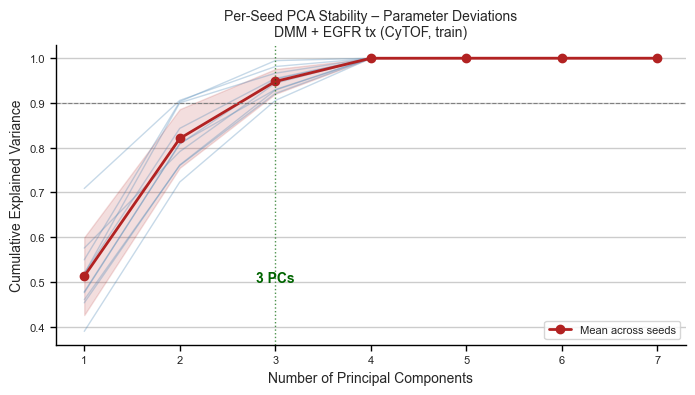


Cumulative variance at 3 PCs across seeds: 94.8% ± 2.8%
  Range: [90.5%, 99.5%]


In [38]:
# --- Per-seed PCA stability: explained variance across seeds ---
# (Uses full PCA per seed, not just 3 PCs, to show the elbow)

per_seed_explained = []
for job, grp in subset_pca.groupby("job"):
    X_seed = grp.set_index("cell_line")[param_cols_sig]
    X_s = StandardScaler().fit_transform(X_seed.values)
    _pca = PCA().fit(X_s)
    cumvar_seed = np.cumsum(_pca.explained_variance_ratio_)
    per_seed_explained.append(
        pd.DataFrame({
            "PC": range(1, len(cumvar_seed) + 1),
            "cumvar": cumvar_seed,
            "indvar": _pca.explained_variance_ratio_,
            "seed": job,
        })
    )

per_seed_df = pd.concat(per_seed_explained, ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=per_seed_df, x="PC", y="cumvar", units="seed",
             estimator=None, alpha=0.3, color="steelblue", ax=ax, lw=1)
agg = per_seed_df.groupby("PC")["cumvar"].agg(["mean", "std"]).reset_index()
ax.plot(agg["PC"], agg["mean"], "o-", color="firebrick", lw=2, label="Mean across seeds")
ax.fill_between(agg["PC"], agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                alpha=0.15, color="firebrick")

ax.axhline(0.9, ls="--", color="gray", lw=0.8)
ax.axvline(3, ls=":", color="darkgreen", lw=1, alpha=0.7)
ax.annotate("3 PCs", xy=(3, 0.5), fontsize=10, color="darkgreen", fontweight="bold", ha="center")

ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title(f"Per-Seed PCA Stability – Parameter Deviations\n{model_label} ({context_label}, train)")
ax.legend(loc="lower right")
configure_axis_spines(ax)
fig.tight_layout()
plt.show()

at3 = per_seed_df[per_seed_df.PC == 3]["cumvar"]
print(f"\nCumulative variance at 3 PCs across seeds: {at3.mean():.1%} ± {at3.std():.1%}")
print(f"  Range: [{at3.min():.1%}, {at3.max():.1%}]")

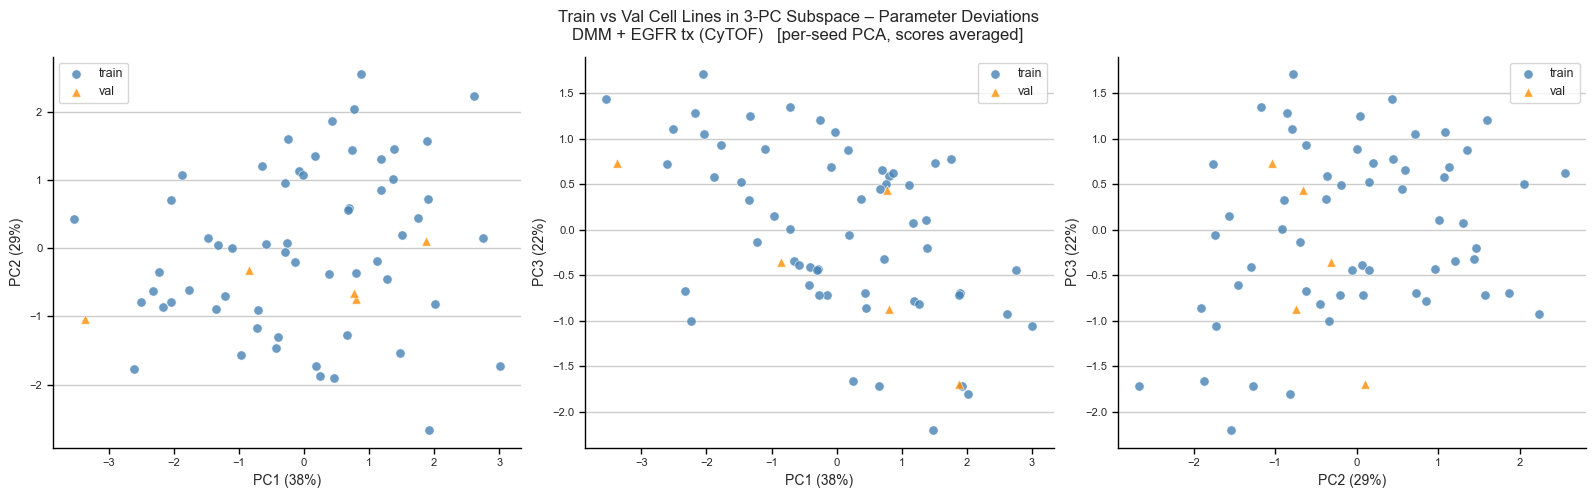


Per-seed PCA (3 PCs) explains 90.2% ± 6.6% of val variance


In [ ]:
# --- Train vs Val: project val deviations using per-seed PCA ---
subset_val = param_devs_df[
    (param_devs_df.context == "cytof_init") & (param_devs_df.dataset == "val")
].copy()

all_val_scores = []
for job, grp in subset_val.groupby("job"):
    if job not in seed_scalers:
        continue  # skip if this seed wasn't in train
    X_val_seed = grp.set_index("cell_line")[param_cols_sig]
    X_vs = seed_scalers[job].transform(X_val_seed.values)
    scores_v = X_vs @ seed_components[job].T
    df_v = pd.DataFrame(scores_v, index=X_val_seed.index, columns=pc_labels)
    df_v["seed"] = job
    all_val_scores.append(df_v)

val_scores_df = pd.concat(all_val_scores)
mean_val = val_scores_df.groupby(level=0)[pc_labels].mean().reset_index()
mean_val.columns = ["cell_line"] + pc_labels
mean_val["split"] = "val"

mean_train = cell_pca_scores.reset_index()
mean_train.columns = ["cell_line"] + pc_labels
mean_train["split"] = "train"

combined = pd.concat([mean_train, mean_val], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (xpc, ypc) in zip(axes, [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3")]):
    xi, yi = int(xpc[-1]) - 1, int(ypc[-1]) - 1
    for split, color, marker in [("train", "steelblue", "o"), ("val", "darkorange", "^")]:
        sub = combined[combined.split == split]
        ax.scatter(sub[xpc], sub[ypc], alpha=0.8, s=45, color=color, marker=marker,
                   edgecolors="white", linewidth=0.5, label=split)
    ax.set_xlabel(f"{xpc} ({mean_explained[int(xpc[-1])-1]:.0%})")
    ax.set_ylabel(f"{ypc} ({mean_explained[int(ypc[-1])-1]:.0%})")
    ax.legend(fontsize=9)
    configure_axis_spines(ax)

fig.suptitle(
    f"Train vs Val Cell Lines in 3-PC Subspace – Parameter Deviations\n"
    f"{model_label} ({context_label})   [per-seed PCA, scores averaged]",
    fontsize=12,
)
fig.tight_layout()
plt.show()

# Explained variance on val: project each seed, compute residual
val_explained_per_seed = []
for job, grp in subset_val.groupby("job"):
    if job not in seed_scalers:
        continue
    X_val_seed = grp.set_index("cell_line")[param_cols_sig]
    X_vs = seed_scalers[job].transform(X_val_seed.values)
    proj = X_vs @ seed_components[job].T @ seed_components[job]
    total = np.var(X_vs, axis=0).sum()
    resid = np.var(X_vs - proj, axis=0).sum()
    val_explained_per_seed.append(1 - resid / total if total > 0 else np.nan)

print(f"\nPer-seed PCA (3 PCs) explains {np.nanmean(val_explained_per_seed):.1%} "
      f"± {np.nanstd(val_explained_per_seed):.1%} of val variance")